In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/thedevastator/youtube-trending-videos-dataset/youtube.csv


In [2]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/thedevastator/youtube-trending-videos-dataset/youtube.csv")
df.head()

,index,video_id,trending_date,title,channel_title,category_id,publish_date,time_frame,published_day_of_week,publish_country,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed
0,0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,13/11/2017,17:00 to 17:59,Monday,US,SHANtell martin,748374,57527,2966,15954,False,False,False
1,1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,13/11/2017,7:00 to 7:59,Monday,US,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,False,False,False
2,2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,12/11/2017,19:00 to 19:59,Sunday,US,"racist superman|""rudy""""|""""mancuso""""|""""king""""|""...",3191434,146033,5339,8181,False,False,False
3,3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,13/11/2017,11:00 to 11:59,Monday,US,"rhett and link|""gmm""""|""""good mythical morning""...",343168,10172,666,2146,False,False,False
4,4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,12/11/2017,18:00 to 18:59,Sunday,US,"ryan|""higa""""|""""higatv""""|""""nigahiga""""|""""i dare ...",2095731,132235,1989,17518,False,False,False


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161470 entries, 0 to 161469
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   index                   161470 non-null  int64 
 1   video_id                161470 non-null  object
 2   trending_date           161470 non-null  object
 3   title                   161470 non-null  object
 4   channel_title           161470 non-null  object
 5   category_id             161470 non-null  int64 
 6   publish_date            161470 non-null  object
 7   time_frame              161470 non-null  object
 8   published_day_of_week   161470 non-null  object
 9   publish_country         161470 non-null  object
 10  tags                    161470 non-null  object
 11  views                   161470 non-null  int64 
 12  likes                   161470 non-null  int64 
 13  dislikes                161470 non-null  int64 
 14  comment_count           161470 non-n

index                     0
video_id                  0
trending_date             0
title                     0
channel_title             0
category_id               0
publish_date              0
time_frame                0
published_day_of_week     0
publish_country           0
tags                      0
views                     0
likes                     0
dislikes                  0
comment_count             0
comments_disabled         0
ratings_disabled          0
video_error_or_removed    0
dtype: int64

In [19]:
df['trending_date'] = pd.to_datetime(
    df['trending_date'],
    format='%y.%d.%m'
)

In [13]:
df['engagement_score'] = (
    df['likes'] + df['comment_count'] - df['dislikes']
) / df['views']

In [15]:
df['estimated_revenue'] = df['views'] * 0.01

In [22]:
df['trending_date'] = pd.to_datetime(
    df['trending_date'],
    format='%y.%d.%m',
    errors='coerce'
)

df['publish_date'] = pd.to_datetime(
    df['publish_date'],
    errors='coerce'
)

df = df.dropna(subset=['trending_date','publish_date'])

/tmp/ipykernel_55/1167455968.py:7: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['publish_date'] = pd.to_datetime(


In [18]:
df['high_demand'] = (
    df['views'] > df['views'].median()
).astype(int)

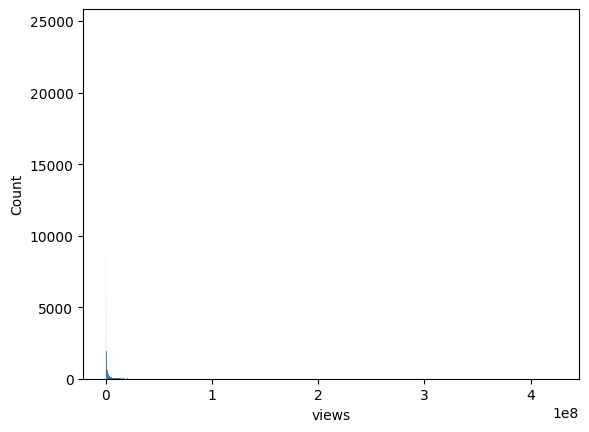

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['views'])
plt.show()

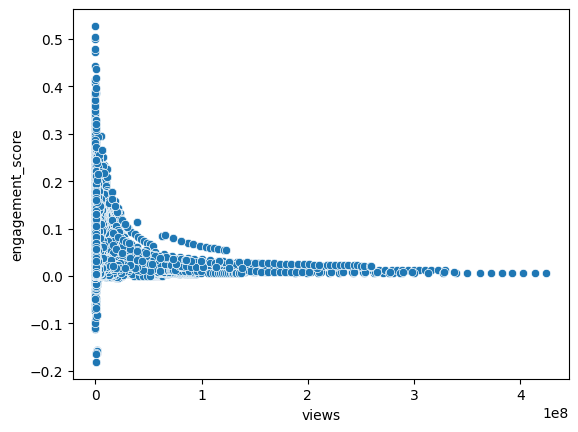

In [24]:
sns.scatterplot(x='views', y='engagement_score', data=df)
plt.show()

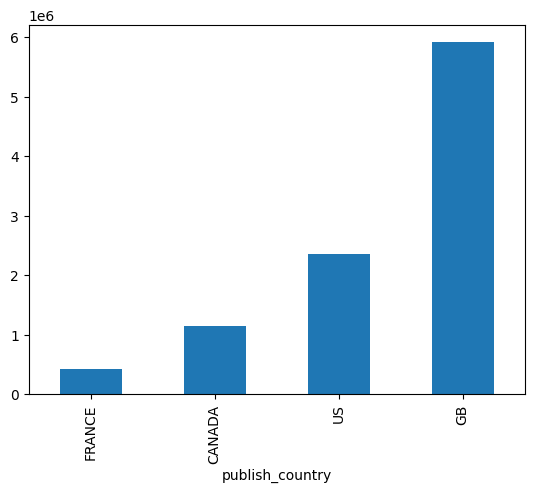

In [25]:
df.groupby('publish_country')['views'].mean().sort_values().plot(kind='bar')
plt.show()

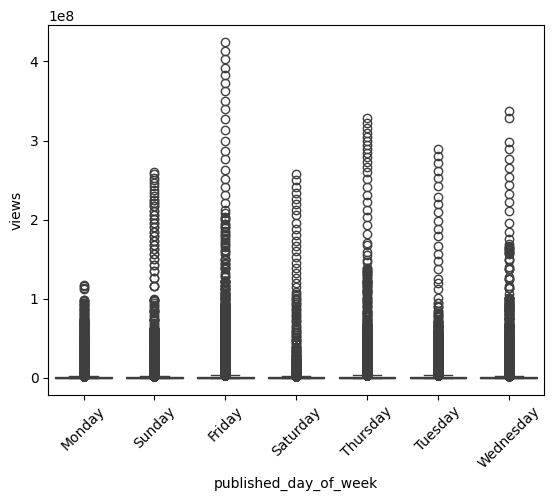

In [26]:
sns.boxplot(x='published_day_of_week', y='views', data=df)
plt.xticks(rotation=45)
plt.show()

In [28]:
from sklearn.preprocessing import StandardScaler

features = df[['views','likes','comment_count','engagement_score']]

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

In [29]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled)

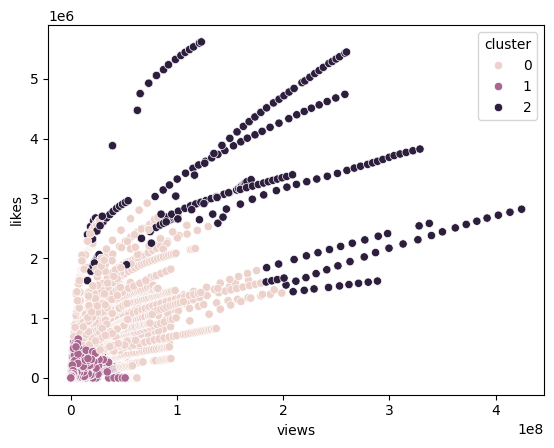

In [30]:
sns.scatterplot(x=df['views'], y=df['likes'], hue=df['cluster'])
plt.show()

In [ ]:
Cluster 0 → Low demand videos (low revenue)
Cluster 1 → Medium demand videos
Cluster 2 → High revenue potential videos

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = df[['likes','comment_count','dislikes','engagement_score']]
y = df['high_demand']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = LogisticRegression()
model.fit(X_train,y_train)

pred = model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.9433640924010652


Demand-Supply Analysis
	•	Views represent consumer demand.
	•	High engagement increases demand.

Revenue Optimization
	•	High engagement → more advertising revenue.

Pricing Strategy
	•	Advertisers should invest more in high-demand content.

Risk Analysis
	•	Low engagement videos → risky investment.